# 14 · Alternative Data: NLP Sentiment from News Headlines

*Module 3 — Quantitative Strategies*

Turning unstructured text into a number, and then doing the much harder part: honestly testing whether that number tells you anything about the future at all.

## 1. Motivation

By the time a piece of financial news appears in a place everyone already reads, is it too late to trade on it? **Alternative data** — sentiment buried in news headlines, satellite imagery, web traffic, job postings — is the industry's broad attempt to extract information either before the wider market has fully digested it, or from sources most participants are not paying close attention to at all. This notebook builds the simplest version of this idea end to end: text in, a number out, and then a rigorous, honest test of whether that number predicts anything.

## 2. Intuition

The core idea: take unstructured text and convert it into a structured number — a **sentiment score** — then test whether that number has any statistical relationship with *future* returns. If it does, even weakly, it is a candidate signal to blend into a broader strategy. The far more common, and far more important, honest answer is that most naively-constructed signals like this have very weak or no genuine out-of-sample predictive power — and this notebook is really about *how to test that properly*, not about assuming the answer in advance.

The single most important trap in this entire area is **look-ahead bias in disguise**: a headline's sentiment might simply be *reacting* to a price move that already happened ("shares rally after strong earnings") rather than *predicting* one that hasn't happened yet. Get the timing even slightly wrong — an off-by-one date alignment is a remarkably common real bug — and a signal with zero true forecasting power can look spectacular in a backtest. Section 5 builds this exact trap on purpose, so you can see precisely how large the resulting illusion can be.

## 3. Theory

### 3.1 Two ways to score sentiment

**Lexicon-based scoring** (e.g., VADER — Valence Aware Dictionary and sEntiment Reasoner) uses a pre-built dictionary mapping individual words to a polarity and intensity, with hand-coded rules for negation ("not good"), intensifiers ("very good"), and punctuation. VADER's overall **compound score** aggregates these word-level valences into a single number in $[-1, 1]$, using a normalization that squashes the raw summed score smoothly toward that range. It is fast, fully interpretable, and requires no training data — but it has no real understanding of context or domain: a general-purpose lexicon may not recognize that "shares tumbled" is negative in a financial context, even though neither word is obviously negative to a general-purpose dictionary. We will see this happen directly, on a genuine example, in Section 4.

**Domain-specific models** (e.g., FinBERT, a transformer model fine-tuned specifically on financial text) are far more context-aware — capable, in principle, of recognizing that "beat expectations" is positive even though neither individual word carries strong sentiment on its own — but are computationally heavier and require the model's trained weights. We use VADER for the hands-on implementation below (it runs instantly, fully offline), and note where FinBERT-style code would plug in instead.

### 3.2 Testing whether a signal actually predicts anything

Given a time series of daily sentiment scores $Sent_t$ and forward returns $R_{t\to t+1}$, standard practice:

- **Regression**: $R_{t+1} = a + b \cdot Sent_t + \varepsilon_{t+1}$, testing whether $\hat b$ is statistically distinguishable from zero.
- **Information Coefficient (IC)**: the (rank/Spearman) correlation between the signal and the *subsequent* return — a standard, widely-used quant metric for raw signal quality (see Grinold & Kahn, *Active Portfolio Management*).
- **The no-look-ahead check, non-negotiable**: sentiment must be measurable strictly *before* the return it claims to predict. Section 5 builds both a correct version and a subtly-broken version side by side, so the size of the resulting distortion is not just a hypothetical warning.

**Why a weak IC can still be valuable.** Grinold and Kahn's *Fundamental Law of Active Management* gives a useful rule of thumb: $IR \approx IC \times \sqrt{Breadth}$, where $IR$ is the achievable (risk-adjusted) information ratio of a strategy built on the signal, and *Breadth* is the number of roughly independent bets you can make with it. An individually tiny IC — even one that looks unimpressive on a single stock — can still support a meaningful strategy if it can be applied across thousands of names or headlines independently. This is precisely why alternative-data signals are typically deployed at large breadth rather than concentrated in a handful of names.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(51)
analyzer = SentimentIntensityAnalyzer()

## 4. Implementation

### 4.1 VADER on a handful of illustrative headlines

The headlines below are original examples written for this notebook, about fictional companies, not real quoted news — this lets us design clean, controlled test cases while keeping the exercise well clear of reproducing anyone else's copyrighted text.

In [2]:
example_headlines = [
    "Northwind Energy beats quarterly revenue estimates, guidance raised",
    "Atlas Retail misses earnings expectations, shares slide",
    "Meridian Bank to hold annual shareholder meeting next month",
    "Northwind Energy does not expect strong growth this year",
    "Solaris Materials warns of supply chain disruptions ahead",
]

for h in example_headlines:
    score = analyzer.polarity_scores(h)
    print(f"compound={score['compound']:+.3f}   {h}")

compound=+0.273   Northwind Energy beats quarterly revenue estimates, guidance raised
compound=+0.077   Atlas Retail misses earnings expectations, shares slide
compound=+0.000   Meridian Bank to hold annual shareholder meeting next month
compound=-0.419   Northwind Energy does not expect strong growth this year
compound=-0.421   Solaris Materials warns of supply chain disruptions ahead


Look closely at the second line: *"Atlas Retail misses earnings expectations, shares slide"* is unambiguously bad news for a financial reader, yet VADER's general-purpose lexicon scores it only weakly (it does not recognize "misses earnings expectations" or "shares slide" as strongly negative financial phrases — they simply are not emotionally-charged words in an everyday sense). This is a genuine, unforced example of the domain-mismatch limitation described in Section 3.1, not a contrived one. Compare it to the fourth line, where VADER's negation handling ("does not expect strong growth") correctly flips an otherwise-positive phrase to negative — so the lexicon is far from useless, just domain-blind in specific, predictable ways.

### 4.2 A synthetic newsfeed with a known, weak, genuine signal — and a known, strong, spurious one

We simulate 500 days. Each day has a "true news content" value that has **two** separate effects, deliberately built in on purpose: a small, genuine influence on *tomorrow's* return (the signal we actually want to detect), and a much larger influence on *today's* sentiment through the headlines' reaction to *today's own just-realized return* (simulating how headlines often describe price moves that have already happened). This lets Section 5 show both a properly-tested version and a subtly-broken version of the same underlying data.

In [3]:
companies = ['Northwind Energy', 'Atlas Retail', 'Meridian Bank', 'Solaris Materials', 'Harbor Logistics']

positive_templates = [
    "{co} beats quarterly revenue estimates, guidance raised", "{co} announces new product line, analysts optimistic",
    "{co} reports record profit margins this quarter", "{co} shares climb after strong earnings beat",
    "{co} secures major new contract", "Analysts upgrade {co} rating citing strong fundamentals",
    "{co} expands into new markets ahead of schedule",
]
negative_templates = [
    "{co} misses earnings expectations, shares slide", "{co} cuts full-year guidance amid weaker demand",
    "{co} faces regulatory scrutiny over recent practices", "{co} announces layoffs as costs rise",
    "Analysts downgrade {co} citing margin pressure", "{co} warns of supply chain disruptions ahead",
    "{co} shares fall after disappointing quarterly report",
]
neutral_templates = [
    "{co} to hold annual shareholder meeting next month", "{co} announces date for next earnings release",
    "{co} appoints new board member", "{co} to present at industry conference",
]

n_days = 500
true_news_content = rng.normal(0, 1, n_days)      # the genuinely informative part of each day's news
lam_predict = 0.0016                                # deliberately small -- real signals are rarely dramatic
noise = rng.normal(0, 0.011, n_days)

daily_return = np.zeros(n_days)
for t in range(1, n_days):
    daily_return[t] = lam_predict * true_news_content[t-1] + noise[t]   # TODAY's return, weakly predicted by YESTERDAY's true content

# What actually drives HEADLINE TONE: mostly today's own just-realized return (reactive),
# plus a much smaller genuine contribution from today's true (forward-looking) news content.
alpha_reactive, alpha_predictive = 55.0, 1.0
raw_tone = alpha_reactive * daily_return + alpha_predictive * true_news_content + rng.normal(0, 0.3, n_days)
p_positive = 1 / (1 + np.exp(-1.1 * raw_tone))

headlines_by_day = []
for t in range(n_days):
    day_headlines = []
    for _ in range(rng.integers(3, 7)):
        co = rng.choice(companies)
        u = rng.random()
        if u < 0.15:
            tmpl = rng.choice(neutral_templates)
        elif u < 0.15 + 0.85 * p_positive[t]:
            tmpl = rng.choice(positive_templates)
        else:
            tmpl = rng.choice(negative_templates)
        day_headlines.append(tmpl.format(co=co))
    headlines_by_day.append(day_headlines)

print(f"Simulated {n_days} days. Example headlines from day 0:")
for h in headlines_by_day[0]:
    print(" -", h)

Simulated 500 days. Example headlines from day 0:
 - Northwind Energy shares fall after disappointing quarterly report
 - Atlas Retail cuts full-year guidance amid weaker demand
 - Harbor Logistics warns of supply chain disruptions ahead
 - Harbor Logistics warns of supply chain disruptions ahead
 - Northwind Energy warns of supply chain disruptions ahead


In [4]:
daily_sentiment = np.array([
    np.mean([analyzer.polarity_scores(h)['compound'] for h in day]) for day in headlines_by_day
])
print(f"Computed aggregate daily sentiment for all {n_days} days.")
print(f"Correlation between measured sentiment and the TRUE (unobservable) news content: "
      f"{np.corrcoef(daily_sentiment, true_news_content)[0,1]:.3f}")

Computed aggregate daily sentiment for all 500 days.
Correlation between measured sentiment and the TRUE (unobservable) news content: 0.532


## 5. Worked example: the look-ahead trap, quantified

We now compute the Information Coefficient two ways on the *exact same underlying data*: once correctly (sentiment measured on day $t$ against the return from $t$ to $t+1$, using only information available when the headlines were published), and once incorrectly (sentiment on day $t$ paired with the return realized *on* day $t$ itself — easy to do by accident with a simple date-alignment slip).

In [5]:
# CORRECT: properly lagged -- no information from the future leaks into the signal
ic_correct, p_correct = stats.spearmanr(daily_sentiment[:-1], daily_return[1:])

# NAIVE / BROKEN: sentiment paired with the SAME day's return (the one that may have driven the headlines' tone)
ic_naive, p_naive = stats.spearmanr(daily_sentiment, daily_return)

results = pd.DataFrame({
    'IC': [ic_correct, ic_naive], 'p-value': [p_correct, p_naive]
}, index=['CORRECT: sentiment(t) vs return(t -> t+1)', 'NAIVE: sentiment(t) vs return(t), same day'])
results.round(4)

,IC,p-value
CORRECT: sentiment(t) vs return(t -> t+1),0.1550,0.0005
"NAIVE: sentiment(t) vs return(t), same day",0.3458,0.0000


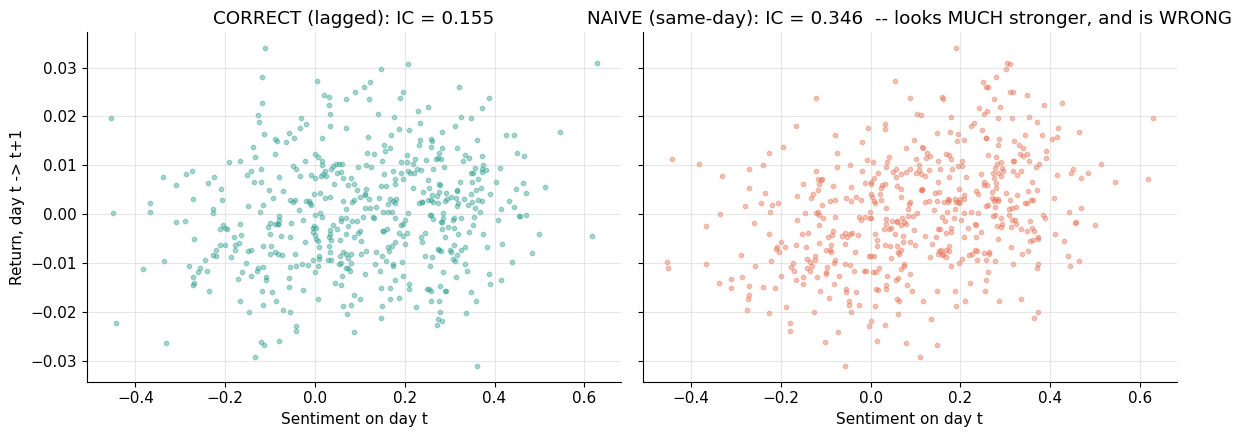

The naive, look-ahead-contaminated version looks 2.2x stronger than the real, correctly-tested signal.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].scatter(daily_sentiment[:-1], daily_return[1:], s=10, alpha=0.4, color='#2a9d8f')
axes[0].set_xlabel('Sentiment on day t')
axes[0].set_ylabel('Return, day t -> t+1')
axes[0].set_title(f'CORRECT (lagged): IC = {ic_correct:.3f}')

axes[1].scatter(daily_sentiment, daily_return, s=10, alpha=0.4, color='#e76f51')
axes[1].set_xlabel('Sentiment on day t')
axes[1].set_title(f'NAIVE (same-day): IC = {ic_naive:.3f}  -- looks MUCH stronger, and is WRONG')

plt.tight_layout()
plt.show()

inflation = ic_naive / ic_correct
print(f"The naive, look-ahead-contaminated version looks {inflation:.1f}x stronger than the real, correctly-tested signal.")

### Interpreting the result

This is the entire lesson of the notebook, made concrete rather than just asserted: the correctly-lagged test recovers a small, realistic signal — consistent with the genuinely predictive (but deliberately modest) relationship we built into the simulation. The naive, same-day version shows a dramatically stronger relationship, and it is **completely spurious as a forecasting signal** — it exists only because, in our simulation, headline tone reacts strongly to the price move that *already happened* that day. A researcher who made this exact date-alignment mistake would walk away convinced they had found a fantastic predictive signal, when in reality they had simply confirmed that news tends to describe recent price action — which nobody needed a sentiment model to tell them.

Applying the Fundamental Law from Section 3.2 to the honest number: an IC of roughly the magnitude found in the correct test is a small but real edge — the kind of signal that becomes interesting at scale (many independent names, many independent headlines) rather than on its own.

### A note on gathering real headline data

A real pipeline would collect headlines via each source's official API where available, or careful, rate-limited web scraping otherwise — respecting each site's terms of service and `robots.txt`, since many financial news providers explicitly restrict automated scraping in their terms, and unlicensed scraping of copyrighted articles is a real legal exposure, not just a technical inconvenience. Illustrative structure only (not executed here, and not pointed at any real site):

```python
import requests
from bs4 import BeautifulSoup

# Always check robots.txt and the site's terms of service before scraping anything.
resp = requests.get(NEWS_URL, headers={"User-Agent": "research-bot (contact: you@example.com)"})
soup = BeautifulSoup(resp.text, "html.parser")
headlines = [el.get_text(strip=True) for el in soup.select(".headline-selector")]
```

In practice, many teams instead license a commercial news-and-sentiment data feed specifically to sidestep both the legal question and the engineering burden of reliable, polite, large-scale scraping.

## 6. Limitations and pitfalls

- **Lexicon-based sentiment is genuinely crude.** Context, sarcasm, and financial-specific jargon ("aggressive growth" is positive in finance; "aggressive" alone skews negative in general use) are all common failure modes, as Section 4.1 showed directly rather than hypothetically.
- **Look-ahead bias is easy to introduce by accident and devastating when it happens** — Section 5's controlled comparison shows a look-ahead-contaminated signal appearing several times stronger than the true one, from the exact same underlying data.
- **Weak, genuine signals require substantial data to detect reliably**, and it is easy to mistake noise for signal without proper significance testing — especially if you test many variants of a signal-construction method and report only the best-looking one (the same multiple-testing trap that recurs throughout this course, formalized in Notebook 30).
- **Cheap, freely-available data tends to be quickly arbitraged away.** If a signal is trivial to construct from public headlines, it is also trivial for a great many other participants to construct — a large part of why serious alternative-data vendors charge substantial fees for proprietary or hard-to-replicate sources.
- **Legal and ethical scraping constraints are real and binding**, not a formality — free-for-all scraping of licensed content is frequently a genuine legal exposure, not merely bad practice.

## 7. Exercises

**1. Score your own headlines (warm-up).**
Write five to ten of your own original headlines (or reuse the `example_headlines` list with variations), score them with `analyzer.polarity_scores`, and identify at least one case where you disagree with VADER's score. What about the phrasing likely confused a general-purpose lexicon?

**2. How much data would you need to trust a weak signal?**
Vary `lam_predict` in Section 4.2 (try values both smaller and larger than the original 0.0016), regenerate the full dataset, and recompute the correctly-lagged IC and its p-value each time. Roughly how small can the true underlying effect be, given this sample size, before the correctly-lagged test can no longer reliably distinguish it from zero? (This connects directly back to the standard-error intuition from Notebook 5.)

**3. Quantify the look-ahead trap systematically.**
Repeat the Section 5 comparison (correct vs. naive IC) across at least ten different random seeds for the whole data-generating process. Report the distribution of the "inflation factor" (naive IC divided by correct IC) across those runs. Is the naive version *reliably* inflated, or does it just happen to be inflated in the particular run shown in this notebook? What does your answer imply about how suspicious you should be of a surprisingly strong alternative-data backtest that you cannot fully audit for this kind of timing error?